In [1]:
# === IMPORTS ===
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import os
import urllib.request
import zipfile

In [2]:
# === DOWNLOAD THE DATASET ===
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00224/Dataset.zip"
zip_path = "gas_sensor_dataset.zip"

print("Downloading dataset...")
urllib.request.urlretrieve(url, zip_path)
print("Download complete.")

# Extract
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("gas_data")
print("Extraction complete.")

Download complete.
Extraction complete.


In [3]:
# === LOAD THE DATA ===
# The dataset has 10 batch files
# Format per line: class_label feature1 feature2 ... feature128
# Features are in format: sensor_id:value

import re

all_features = []
all_labels = []

data_dir = "gas_data/Dataset"

for batch_num in range(1, 11):  # batch1.dat to batch10.dat
    filepath = os.path.join(data_dir, f"batch{batch_num}.dat")
    
    with open(filepath, 'r') as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            
            parts = line.split()
            
            # First element: "class;concentration" → we want the class
            label_part = parts[0]
            label = int(label_part.split(';')[0])
            
            # Remaining elements: "feature_id:value"
            features = []
            for part in parts[1:]:
                value = float(part.split(':')[1])
                features.append(value)
            
            all_features.append(features)
            all_labels.append(label)

# Convert to arrays
X = np.array(all_features)
y = np.array(all_labels)

print(f"Total samples: {X.shape[0]}")
print(f"Total features: {X.shape[1]}")
print(f"Classes: {np.unique(y)}")
print(f"Number of classes: {len(np.unique(y))}")
print(f"Samples per class:")
for c in np.unique(y):
    print(f"  Class {c}: {np.sum(y == c)} samples")

Total samples: 13910
Total features: 128
Classes: [1 2 3 4 5 6]
Number of classes: 6
Samples per class:
  Class 1: 2565 samples
  Class 2: 2926 samples
  Class 3: 1641 samples
  Class 4: 1936 samples
  Class 5: 3009 samples
  Class 6: 1833 samples


In [7]:
# === MAKE LABELS START FROM 0 ===
# Labels are 1-6, we need 0-5 for sparse_categorical_crossentropy
y = y - 1  # Now labels are 0, 1, 2, 3, 4, 5

print(f"Labels after adjustment: {np.unique(y)}")

# === CHECK FOR MISSING VALUES ===
print(f"\nAny NaN values: {np.isnan(X).any()}")
print(f"Any infinite values: {np.isinf(X).any()}")

# If there are any, handle them:
# Replace NaN with column mean
if np.isnan(X).any():
    from sklearn.impute import SimpleImputer
    imputer = SimpleImputer(strategy='mean')
    X = imputer.fit_transform(X)
    print("NaN values handled with mean imputation.")

# Replace infinite values
if np.isinf(X).any():
    X = np.where(np.isinf(X), np.nan, X)
    from sklearn.impute import SimpleImputer
    imputer = SimpleImputer(strategy='mean')
    X = imputer.fit_transform(X)
    print("Infinite values handled.")

print("Data is clean.")

# === TRAIN-TEST SPLIT ===
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

Labels after adjustment: [-2 -1  0  1  2  3]

Any NaN values: False
Any infinite values: False
Data is clean.
Training set: 11128 samples
Test set: 2782 samples


In [8]:
# === NORMALIZE THE DATA ===
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)  # Use SAME scaler!

print(f"\nBefore scaling - Train mean: {X_train[:, 0].mean():.4f}, std: {X_train[:, 0].std():.4f}")
print(f"After scaling  - Train mean: {X_train_scaled[:, 0].mean():.4f}, std: {X_train_scaled[:, 0].std():.4f}")


Before scaling - Train mean: 50574.7635, std: 69771.9455
After scaling  - Train mean: 0.0000, std: 1.0000


In [9]:
# === METHOD 1: SelectKBest with ANOVA F-score ===
# ANOVA F-test measures how different the feature values are across classes
# High F-score = feature is very different for different gases = USEFUL

from sklearn.feature_selection import SelectKBest, f_classif

# Select top 20 features
k_best = 20
selector = SelectKBest(score_func=f_classif, k=k_best)
X_train_selected = selector.fit_transform(X_train_scaled, y_train)
X_test_selected = selector.transform(X_test_scaled)

print(f"Features reduced: {X_train_scaled.shape[1]} → {X_train_selected.shape[1]}")
print(f"\nSelected feature indices: {selector.get_support(indices=True)}")
print(f"\nTop feature scores:")

# Show the scores for all features
scores = selector.scores_
top_indices = np.argsort(scores)[::-1][:k_best]
for i, idx in enumerate(top_indices):
    print(f"  Feature {idx}: F-score = {scores[idx]:.2f}")

Features reduced: 128 → 20

Selected feature indices: [  0   2   3   8  10  11  13  14  64  66  67  68  69  72  74  76  83  91
  99 115]

Top feature scores:
  Feature 8: F-score = 2750.32
  Feature 64: F-score = 2183.28
  Feature 10: F-score = 2096.36
  Feature 11: F-score = 1865.38
  Feature 13: F-score = 1787.80
  Feature 66: F-score = 1779.31
  Feature 67: F-score = 1608.63
  Feature 72: F-score = 1594.96
  Feature 68: F-score = 1554.80
  Feature 0: F-score = 1506.33
  Feature 69: F-score = 1465.11
  Feature 74: F-score = 1334.33
  Feature 99: F-score = 1295.24
  Feature 83: F-score = 1292.50
  Feature 14: F-score = 1284.70
  Feature 2: F-score = 1277.88
  Feature 115: F-score = 1270.61
  Feature 91: F-score = 1225.25
  Feature 76: F-score = 1224.08
  Feature 3: F-score = 1222.49


In [10]:
# === FINAL FEATURE SELECTION ===
# We'll use the SelectKBest result
X_train_final = X_train_selected  # Shape: (n_samples, 20)
X_test_final = X_test_selected    # Shape: (n_samples, 20)

print(f"\nFinal training data shape: {X_train_final.shape}")
print(f"Final test data shape: {X_test_final.shape}")


Final training data shape: (11128, 20)
Final test data shape: (2782, 20)


In [15]:
# === SAFER FIX: Use LabelEncoder ===
from sklearn.preprocessing import LabelEncoder

# First, get the original labels before any subtraction
# Combine train and test to ensure consistent encoding
all_labels = np.concatenate([y_train, y_test])
print("Current unique labels:", np.unique(all_labels))

# LabelEncoder automatically maps any values to 0, 1, 2, 3, ...
le = LabelEncoder()
le.fit(all_labels)

y_train = le.transform(y_train)
y_test = le.transform(y_test)

print("Fixed train labels:", np.unique(y_train))
print("Fixed test labels:", np.unique(y_test))
print("Number of classes:", len(le.classes_))

Current unique labels: [-2 -1  0  1  2  3]
Fixed train labels: [0 1 2 3 4 5]
Fixed test labels: [0 1 2 3 4 5]
Number of classes: 6


In [23]:
# Verify everything is clean
print("X_train_final shape:", X_train_final.shape)
print("y_train labels:", np.unique(y_train))
print("Any NaN:", np.isnan(X_train_final).any())

# Rebuild model (fresh weights)
num_classes = len(np.unique(y_train))  # Should be 6

model = keras.Sequential([
    layers.Input(shape=(20,)),
    layers.Dense(64, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train
history = model.fit(
    X_train_final, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_test_final, y_test),
    verbose=1
)

X_train_final shape: (11128, 20)
y_train labels: [0 1 2 3 4 5]
Any NaN: False
Epoch 1/50
348/348 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.7610 - loss: 0.7249 - val_accuracy: 0.9177 - val_loss: 0.3701
Epoch 2/50
348/348 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9287 - loss: 0.3025 - val_accuracy: 0.9127 - val_loss: 0.2538
Epoch 3/50
348/348 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9488 - loss: 0.2181 - val_accuracy: 0.9623 - val_loss: 0.1802
Epoch 4/50
348/348 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9596 - loss: 0.1767 - val_accuracy: 0.9439 - val_loss: 0.1809
Epoch 5/50
348/348 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9676 - loss: 0.1480 - val_accuracy: 0.9748 - val_loss: 0.1309
Epoch 6/50
348/348 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9727 - loss: 0.1281 - val_accuracy: 0.9813 - val_loss: 0.1139
Epoch 7/50
348/348 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9718 - loss: 0.1166 - val_accuracy: 0.9835 - val_loss: 0.0988
Epoch 8/50
348/348 ━━━━━━━

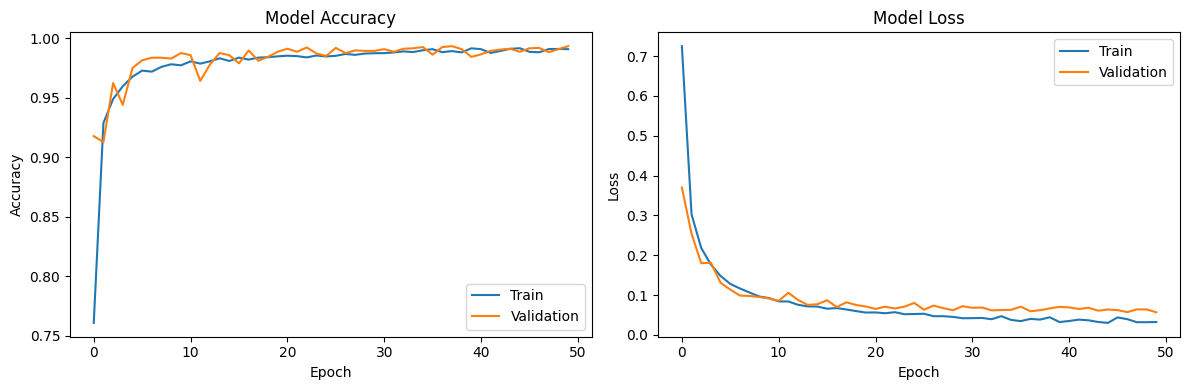

In [24]:
# === OPTIONAL: Plot training history ===
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [25]:
# === CONVERT TO TENSORFLOW LITE (Float32 — no quantization) ===
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_float_model = converter.convert()

# Save it
with open("model_float32.tflite", "wb") as f:
    f.write(tflite_float_model)

print(f"Float32 model saved: {os.path.getsize('model_float32.tflite') / 1024:.2f} KB")

Saved artifact at '/tmp/tmp6r1q26w3'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 20), dtype=tf.float32, name='keras_tensor_12')
Output Type:
  TensorSpec(shape=(None, 6), dtype=tf.float32, name=None)
Captures:
  139973796872016: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139973793009104: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139973793009296: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139973793009872: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139973793008528: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139973793008912: TensorSpec(shape=(), dtype=tf.resource, name=None)
Float32 model saved: 25.17 KB


In [28]:
# === FULL INTEGER QUANTIZATION (int8) ===
# We need to provide representative data for calibration

def representative_dataset():
    for i in range(100):
        sample = X_train_final[i:i+1].astype(np.float32)
        yield [sample]

converter_int8 = tf.lite.TFLiteConverter.from_keras_model(model)
converter_int8.optimizations = [tf.lite.Optimize.DEFAULT]
converter_int8.representative_dataset = representative_dataset
converter_int8.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter_int8.inference_input_type = tf.int8
converter_int8.inference_output_type = tf.int8

tflite_int8_model = converter_int8.convert()

with open("model_int8.tflite", "wb") as f:
    f.write(tflite_int8_model)

print(f"Full Int8 model saved: {os.path.getsize('model_int8.tflite') / 1024:.2f} KB")

Saved artifact at '/tmp/tmpfz37xlt4'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 20), dtype=tf.float32, name='keras_tensor_12')
Output Type:
  TensorSpec(shape=(None, 6), dtype=tf.float32, name=None)
Captures:
  139973796872016: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139973793009104: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139973793009296: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139973793009872: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139973793008528: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139973793008912: TensorSpec(shape=(), dtype=tf.resource, name=None)
Full Int8 model saved: 11.73 KB
Full Int8 model saved: 11.73 KB


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/convert.py:854: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


In [29]:
# === MODEL SIZE COMPARISON ===
float_size = os.path.getsize("model_float32.tflite") / 1024
int8_size = os.path.getsize("model_int8.tflite") / 1024
reduction = (1 - int8_size / float_size) * 100

print("=" * 50)
print("MODEL SIZE COMPARISON")
print("=" * 50)
print(f"{'Model Type':<20} {'Size (KB)':<15}")
print("-" * 35)
print(f"{'Float32':<20} {float_size:<15.2f}")
print(f"{'Int8 Quantized':<20} {int8_size:<15.2f}")
print("-" * 35)
print(f"Size reduction: {reduction:.1f}%")
print("=" * 50)

MODEL SIZE COMPARISON
Model Type           Size (KB)      
-----------------------------------
Float32              25.17          
Int8 Quantized       11.73          
-----------------------------------
Size reduction: 53.4%


In [ ]:
# === INFERENCE COMPARISON ===
def run_tflite_inference(model_path, X_test_data):
    interpreter = tf.lite.Interpreter(model_path=model_path)
    interpreter.allocate_tensors()
    
    input_details = interpreter.get_input_details()
    output_details = interpreter.get_output_details()
    
    # Check input type
    input_dtype = input_details[0]['dtype']
    
    predictions = []
    for i in range(len(X_test_data)):
        sample = np.array([X_test_data[i]], dtype=np.float32)
        
        # Handle int8 input models
        if input_dtype == np.int8:
            input_scale = input_details[0]['quantization'][0]
            input_zero_point = input_details[0]['quantization'][1]
            sample = (sample / input_scale + input_zero_point).astype(np.int8)
        
        interpreter.set_tensor(input_details[0]['index'], sample)
        interpreter.invoke()
        output = interpreter.get_tensor(output_details[0]['index'])
        predictions.append(np.argmax(output))
    
    return np.array(predictions)

print("Running Float32 inference...")
float_preds = run_tflite_inference("model_float32.tflite", X_test_final)

print("Running Default Quantized inference...")
quant_preds = run_tflite_inference("model_quantized.tflite", X_test_final)

print("Running Int8 inference...")
int8_preds = run_tflite_inference("model_int8.tflite", X_test_final)

# Accuracies
float_acc = np.mean(float_preds == y_test) * 100
quant_acc = np.mean(quant_preds == y_test) * 100
int8_acc = np.mean(int8_preds == y_test) * 100

print("\n" + "=" * 55)
print("INFERENCE COMPARISON")
print("=" * 55)
print(f"{'Model':<25} {'Accuracy (%)':<15} {'Size (KB)':<10}")
print("-" * 50)
print(f"{'Float32':<25} {float_acc:<15.2f} {sizes['Small Float32']:<10.2f}")
print(f"{'Default Quantized':<25} {quant_acc:<15.2f} {sizes['Small Quantized']:<10.2f}")
print(f"{'Full Int8':<25} {int8_acc:<15.2f} {sizes['Small Int8']:<10.2f}")
print("=" * 55)